<a href="https://colab.research.google.com/github/dmainagithub/dm-pprl-work/blob/main/Scoping_Review_Work_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Restrat Kernel (for google colab)

In [1]:
## Forcing to restrat runtime
# import os
# os.kill(os.getpid(), 9)

In [2]:
!pip uninstall -y plotly kaleido

Found existing installation: plotly 5.24.1
Uninstalling plotly-5.24.1:
  Successfully uninstalled plotly-5.24.1


In [3]:
# Step 1: Install libraries if needed
# !pip install geopandas
## !pip install -q "plotly>=6.1.1" "kaleido==0.2.1" pycountry wordcloud pandas
!pip install plotly==5.20.0 kaleido==0.2.1 pycountry wordcloud pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 44.6 MB/s eta 0:00:00


In [4]:
# Disable templates
import plotly.io as pio
pio.templates.default = None

In [5]:
# Step 2: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import plotly.express as px
import os
import numpy as np
import pycountry
import plotly.express as px
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from geopy.geocoders import Nominatim
import time

# see all variables
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', True)
pd.set_option('max_colwidth', None)


###** Loading data**

In [6]:
from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/PPRL_data_extraction.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# from google.colab import files
# uploaded = files.upload()

In [8]:
df_raw = pd.read_csv(file_path, dtype=str)  # load everything as str initially
print("Initial rows:", len(df_raw))
df_raw.head()

Initial rows: 653


,search_no,study_title,link,geographic_region,state_country,city,evaluation,date_done,year,topic,lessons_new,reason_idea_for_this_work,aim_objective,steps,background_significance,key_innovation_problem_addressed_purpose,limitations_new,future_work,challenges_,challenges_specify,principles_of_operation,consultation_domain_experts,definition_,interesting_comments,technique_algorithm_method,technique_algorithm_method_notes,technique_evaluated,techniques_mentioned,approach_,approach_mentioned,approach_mentioned_notes,optimization_blocking,disease_specific,domain_,sub_domain,sub_category_domain,data_,study_design_research_design_study_methodology,study_design_research_design_study_methodology_os,context_setting,setting_specify,linkage_quality_measuring_method,evaluation_metrics_,evaluation_metric_spy,performance_evaluation,computation_time,precision_accuracy_ppv,recall_sensitivity,specificity,f1_score,scalability,privacy,statistical_techniques,statistical_techniques_notes,synonyms,Unnamed: 55,Record Linkage overview,laws,Model,identifiers,variables_supported,Steps_specify,Vulnerabilities/weaknesses,Problem statement,Assumptions,Methods validity,Questions / concerns being raised / I am asking,modern_approaches,next section guide,Captured by,Code_link,system_strengths_specification,platform_,Open_Source_proprietary,software_of_implementation,software_of_implementation_notes,type,count,variables_variations,More explanation on AIMS,Sections,Authors,Skimming_through_scanning,fulltext,mendeley_zotero,citations,Authors_x,Databases,author_affiliation
0,0113200911695,k-ANONYMITY: A MODEL FOR PROTECTING PRIVACY,https://www.worldscientific.com/doi/abs/10.1142/S0218488502001648,North America,United States;,NaN,great-practical,1/13/2026,2002,NaN,NaN,NaN,NaN,NaN,NaN,"Datafly, µ-Argus and k-Similar (they guarantee privacy protection)",NaN,NaN,NaN,NaN,NaN,NaN,protecting re-identification of data while ensuring the data remains practically useful.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Daniel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN
1,0113200911946,Preserving confidentiality when sharing medical database with the Cellsecu system,https://doi.org/10.1016/s1386-5056(03)00030-3,Asia,Taiwan,NaN,great-practical,1/13/2026,2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Chiang YC,NaN,NaN,NaN,Int J Med Inform. 2003 Aug;71(1):17-23. doi: 10.1016/s1386-5056(03)00030-3.,Chiang YC,Int J Med Inform,NaN
2,0113200911965,Privacy-preserving data releases for health report generation,https://doi.org/10.3233/978-1-60750-949-3-1268,North America,Pennsylvania;,"Pennsylvania, United States;",great-practical,1/13/2026,2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Boyens C,NaN,NaN,NaN,Stud Health Technol Inform. 2004;107(Pt 2):1268-72.,Boyens C,Stud Health Technol Inform,NaN
3,0113200911956,A smart-card-enabled privacy preserving E-prescription system,https://doi.org/10.1109/titb.2004.824731,Asia,Singapore;,Singapore;,NaN,1/13/2026,2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yang Y,NaN,NaN,NaN,IEEE Trans Inf Technol Biomed. 2004 Mar;8(1):47-58. doi: 10.1109/titb.2004.824

### **Data Processing**

In [9]:
# # Step 6a: Identify year column
# year_col_candidates = ['year', 'publication_year', 'date', 'pub_year']
# year_col = None
# for c in year_col_candidates:
#     if c in df_raw.columns:
#         year_col = c
#         break
# if year_col is None:
#     raise ValueError("Couldn't find a year column. Rename it to 'year' or 'publication_year' etc.")

# # Ensure year is numeric
# df_raw[year_col] = pd.to_numeric(df_raw[year_col], errors='coerce')

# # Remove rows without year for plotting
# df_year = df_raw[df_raw[year_col].notna()].copy()

# # If there are multiple places per row, explode them like we did earlier
# df_year = df_year.assign(
#     **{place_col: df_year[place_col].str.split(";")}
# ).explode(place_col)
# df_year[place_col] = df_year[place_col].str.strip()
# df_year = df_year[df_year[place_col] != ""]

# # Replace zero counts with 1
# df_year[count_col] = df_year[count_col].replace(0, 1)

# # Step 6b: Aggregate counts per year
# df_year_grouped = df_year.groupby(year_col, as_index=False)[count_col].sum()
# df_year_grouped = df_year_grouped.sort_values(year_col)

# print("Publications per year:\n", df_year_grouped)

# # Step 6c: Plot temporal trend
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10,6))
# plt.plot(df_year_grouped[year_col], df_year_grouped[count_col], marker='o', color='steelblue')
# plt.xlabel("Year")
# plt.ylabel("Number of Publications")
# plt.title("Temporal Trend of PPRL Publications")
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.xticks(df_year_grouped[year_col].astype(int), rotation=45)
# plt.tight_layout()
# plt.savefig("temporal_trend_one.png", dpi=300, bbox_inches="tight")
# plt.show()


In [10]:
# Remove trailing semicolons and split into lists
df_raw['countries_list'] = df_raw['state_country'].str.rstrip(';').str.split(';')

# Explode into multiple rows
df_exploded = df_raw.explode('countries_list')

# Clean up spaces and underscores
df_exploded['countries_clean'] = df_exploded['countries_list'].str.replace('_', ' ').str.strip()

# Drop NaNs or empty values
df_exploded = df_exploded[df_exploded['countries_clean'].notna() & (df_exploded['countries_clean'] != '')]

### Geolocator - more time taken here

In [ ]:
import os
import pandas as pd
import time
from geopy.geocoders import Nominatim

file_path = "pprl_geocoded_data.csv"

# 1️⃣ Check if file already exists
if os.path.exists(file_path):

    print("Geocoded file found. Loading existing data...")
    df_exploded = pd.read_csv(file_path)

else:

    print("Geocoded file not found. Running geocoding...")

    # Create geocoding client
    geolocator = Nominatim(user_agent="geoapi", timeout=10)

    # Geocode function
    def geocode_place(place):
        try:
            loc = geolocator.geocode(place)

            # Rate limit protection
            time.sleep(1)

            if loc:
                return pd.Series([loc.latitude, loc.longitude])

        except Exception as e:
            print(f"Error geocoding {place}: {e}")

        return pd.Series([None, None])


    # Apply geocoding
    df_exploded[['lat', 'lon']] = df_exploded['countries_clean'].apply(
        geocode_place
    )

    # 2️⃣ Save the processed dataset
    df_exploded.to_csv(file_path, index=False)

    print("Geocoding completed and saved.")

In [11]:
# # creating a geocoding client using the Nominatim service (OpenStreetMap's geocoding API)
# geolocator = Nominatim(user_agent="geoapi", timeout=10)
# # user_agent => identifying your app to the API

# # This function takes the name of a place and returns the coordinates
# def geocode_place(place):
#     try:
#         # Request coordinates from Nominatim
#         loc = geolocator.geocode(place)

#         # Rate limiting: pause 1 second between requests (# delay to avoid rate limit)
#         time.sleep(1)

#         if loc:
#             # Return latitude and longitude as a pandas Series
#             return pd.Series([loc.latitude, loc.longitude])
#     except Exception as e:
#         # Handle errors (network issues, invalid place, etc.)
#         print(f"Error geocoding {place}: {e}")

#         return pd.Series([None, None])

#     # Return None for both coordinates if no location found or if exception occurred
#     return pd.Series([None, None])


# # Apply with delay
# df_exploded[['lat', 'lon']] = df_exploded['countries_clean'].apply(
#     lambda x: geocode_place(x)
# )

#### Saving the geocoded data

In [30]:
df_exploded.to_csv("/content/drive/MyDrive/pprl_geocoded_data.csv", index=False)

In [12]:
# df_exploded.countries_clean.nunique()
country_map = (
    df_exploded
    .groupby(['countries_clean', 'lat', 'lon']) # groups the rows by these three column
    .size()
    .reset_index(name='count') # Names the count column as 'count'
)


## Countries and PPRL representation

In [13]:
fig = px.scatter_geo(
    country_map,
    lat='lat',
    lon='lon',
    size='count',
    hover_name='countries_clean',
    projection='natural earth',
    title='Country Representation (Bubble Map)',
    template='plotly'
)

fig.show()


### **Folium Visualization**

In [14]:
import folium
m = folium.Map()
for _, row in country_map.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=row['count']/10,  # Scale based on count
        popup=f"{row['countries_clean']}: {row['count']}"
    ).add_to(m)

### Normalize and Identify Columns

In [15]:
# Normalize column names for predictable access
df_raw.columns = df_raw.columns.str.strip().str.lower()

# Identify the place column (state/country)
place_col_candidates = ['state_country'] # , 'state/country', 'country', 'place', 'location'
place_col = None
for c in place_col_candidates:
    if c in df_raw.columns:
        place_col = c
        break
if place_col is None:
    raise ValueError("Couldn't find a column for state/country. Rename it to 'state_country' or 'country' or one of " + str(place_col_candidates))

# Identify count column
count_col = None
for c in ['count', 'n', 'frequency']:
    if c in df_raw.columns:
        count_col = c
        break
if count_col is None:
    df_raw['count'] = 1
    count_col = 'count'
else:
    # Ensure numeric
    df_raw[count_col] = pd.to_numeric(df_raw[count_col], errors='coerce').fillna(0).astype(int)

print(f"Using place column: '{place_col}' and count column: '{count_col}'")
print("First rows of the dataset:")
df_raw.head(1)

Using place column: 'state_country' and count column: 'count'
First rows of the dataset:


,search_no,study_title,link,geographic_region,state_country,city,evaluation,date_done,year,topic,lessons_new,reason_idea_for_this_work,aim_objective,steps,background_significance,key_innovation_problem_addressed_purpose,limitations_new,future_work,challenges_,challenges_specify,principles_of_operation,consultation_domain_experts,definition_,interesting_comments,technique_algorithm_method,technique_algorithm_method_notes,technique_evaluated,techniques_mentioned,approach_,approach_mentioned,approach_mentioned_notes,optimization_blocking,disease_specific,domain_,sub_domain,sub_category_domain,data_,study_design_research_design_study_methodology,study_design_research_design_study_methodology_os,context_setting,setting_specify,linkage_quality_measuring_method,evaluation_metrics_,evaluation_metric_spy,performance_evaluation,computation_time,precision_accuracy_ppv,recall_sensitivity,specificity,f1_score,scalability,privacy,statistical_techniques,statistical_techniques_notes,synonyms,unnamed: 55,record linkage overview,laws,model,identifiers,variables_supported,steps_specify,vulnerabilities/weaknesses,problem statement,assumptions,methods validity,questions / concerns being raised / i am asking,modern_approaches,next section guide,captured by,code_link,system_strengths_specification,platform_,open_source_proprietary,software_of_implementation,software_of_implementation_notes,type,count,variables_variations,more explanation on aims,sections,authors,skimming_through_scanning,fulltext,mendeley_zotero,citations,authors_x,databases,author_affiliation,countries_list
0,0113200911695,k-ANONYMITY: A MODEL FOR PROTECTING PRIVACY,https://www.worldscientific.com/doi/abs/10.1142/S0218488502001648,North America,United States;,NaN,great-practical,1/13/2026,2002,NaN,NaN,NaN,NaN,NaN,NaN,"Datafly, µ-Argus and k-Similar (they guarantee privacy protection)",NaN,NaN,NaN,NaN,NaN,NaN,protecting re-identification of data while ensuring the data remains practically useful.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Daniel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,[United States]


### Explode multiple countries/states in a single cell

In [16]:
# Step 2b: Split multiple places into separate rows
df_exploded = df_raw.copy()

# Replace NaN with empty string first
df_exploded['state_country'] = df_exploded['state_country'].fillna("")

# Split by ";" and strip spaces
df_exploded = df_exploded.assign(
    state_country = df_exploded['state_country'].str.split(";")
).explode('state_country')

# Remove extra spaces
df_exploded['state_country'] = df_exploded['state_country'].str.strip()

# Remove empty strings
df_exploded = df_exploded[df_exploded['state_country'] != ""]

# If count_col is zero, set to 1 (for rows that originally had 0)
df_exploded[count_col] = df_exploded[count_col].replace(0, 1)

# Quick check
df_exploded.head(1)


,search_no,study_title,link,geographic_region,state_country,city,evaluation,date_done,year,topic,lessons_new,reason_idea_for_this_work,aim_objective,steps,background_significance,key_innovation_problem_addressed_purpose,limitations_new,future_work,challenges_,challenges_specify,principles_of_operation,consultation_domain_experts,definition_,interesting_comments,technique_algorithm_method,technique_algorithm_method_notes,technique_evaluated,techniques_mentioned,approach_,approach_mentioned,approach_mentioned_notes,optimization_blocking,disease_specific,domain_,sub_domain,sub_category_domain,data_,study_design_research_design_study_methodology,study_design_research_design_study_methodology_os,context_setting,setting_specify,linkage_quality_measuring_method,evaluation_metrics_,evaluation_metric_spy,performance_evaluation,computation_time,precision_accuracy_ppv,recall_sensitivity,specificity,f1_score,scalability,privacy,statistical_techniques,statistical_techniques_notes,synonyms,unnamed: 55,record linkage overview,laws,model,identifiers,variables_supported,steps_specify,vulnerabilities/weaknesses,problem statement,assumptions,methods validity,questions / concerns being raised / i am asking,modern_approaches,next section guide,captured by,code_link,system_strengths_specification,platform_,open_source_proprietary,software_of_implementation,software_of_implementation_notes,type,count,variables_variations,more explanation on aims,sections,authors,skimming_through_scanning,fulltext,mendeley_zotero,citations,authors_x,databases,author_affiliation,countries_list
0,0113200911695,k-ANONYMITY: A MODEL FOR PROTECTING PRIVACY,https://www.worldscientific.com/doi/abs/10.1142/S0218488502001648,North America,United States,NaN,great-practical,1/13/2026,2002,NaN,NaN,NaN,NaN,NaN,NaN,"Datafly, µ-Argus and k-Similar (they guarantee privacy protection)",NaN,NaN,NaN,NaN,NaN,NaN,protecting re-identification of data while ensuring the data remains practically useful.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Daniel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,[United States]


### Clean Place Names

In [17]:
# Replace NaN with empty string
df_raw[place_col] = df_raw[place_col].fillna("")

# Strip spaces
df_raw[place_col] = df_raw[place_col].str.strip()

# Keep a copy for analysis with all original rows
df_for_analysis = df_raw.copy()


### Explode Multiple Places

In [18]:
# Split multi-place entries separated by ";" into separate rows
df_exploded = df_raw.copy()
df_exploded = df_exploded.assign(
    **{place_col: df_exploded[place_col].str.split(";")}
).explode(place_col)

# Strip extra spaces
df_exploded[place_col] = df_exploded[place_col].str.strip()

# Remove empty strings
df_exploded = df_exploded[df_exploded[place_col] != ""]

# Replace zero counts with 1 to ensure each row is counted
df_exploded[count_col] = df_exploded[count_col].replace(0, 1)

print("Preview of exploded dataset:")
df_exploded.head()

Preview of exploded dataset:


,search_no,study_title,link,geographic_region,state_country,city,evaluation,date_done,year,topic,lessons_new,reason_idea_for_this_work,aim_objective,steps,background_significance,key_innovation_problem_addressed_purpose,limitations_new,future_work,challenges_,challenges_specify,principles_of_operation,consultation_domain_experts,definition_,interesting_comments,technique_algorithm_method,technique_algorithm_method_notes,technique_evaluated,techniques_mentioned,approach_,approach_mentioned,approach_mentioned_notes,optimization_blocking,disease_specific,domain_,sub_domain,sub_category_domain,data_,study_design_research_design_study_methodology,study_design_research_design_study_methodology_os,context_setting,setting_specify,linkage_quality_measuring_method,evaluation_metrics_,evaluation_metric_spy,performance_evaluation,computation_time,precision_accuracy_ppv,recall_sensitivity,specificity,f1_score,scalability,privacy,statistical_techniques,statistical_techniques_notes,synonyms,unnamed: 55,record linkage overview,laws,model,identifiers,variables_supported,steps_specify,vulnerabilities/weaknesses,problem statement,assumptions,methods validity,questions / concerns being raised / i am asking,modern_approaches,next section guide,captured by,code_link,system_strengths_specification,platform_,open_source_proprietary,software_of_implementation,software_of_implementation_notes,type,count,variables_variations,more explanation on aims,sections,authors,skimming_through_scanning,fulltext,mendeley_zotero,citations,authors_x,databases,author_affiliation,countries_list
0,0113200911695,k-ANONYMITY: A MODEL FOR PROTECTING PRIVACY,https://www.worldscientific.com/doi/abs/10.1142/S0218488502001648,North America,United States,NaN,great-practical,1/13/2026,2002,NaN,NaN,NaN,NaN,NaN,NaN,"Datafly, µ-Argus and k-Similar (they guarantee privacy protection)",NaN,NaN,NaN,NaN,NaN,NaN,protecting re-identification of data while ensuring the data remains practically useful.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Daniel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,[United States]
1,0113200911946,Preserving confidentiality when sharing medical database with the Cellsecu system,https://doi.org/10.1016/s1386-5056(03)00030-3,Asia,Taiwan,NaN,great-practical,1/13/2026,2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,Chiang YC,NaN,NaN,NaN,Int J Med Inform. 2003 Aug;71(1):17-23. doi: 10.1016/s1386-5056(03)00030-3.,Chiang YC,Int J Med Inform,NaN,[Taiwan]
2,0113200911965,Privacy-preserving data releases for health report generation,https://doi.org/10.3233/978-1-60750-949-3-1268,North America,Pennsylvania,"Pennsylvania, United States;",great-practical,1/13/2026,2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,Boyens C,NaN,NaN,NaN,Stud Health Technol Inform. 2004;107(Pt 2):1268-72.,Boyens C,Stud Health Technol Inform,NaN,[Pennsylvania]
3,0113200911956,A smart-card-enabled privacy preserving E-prescription system,https://doi.org/10.1109/titb.2004.824731,Asia,Singapore,Singapore;,NaN,1/13/2026,2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,Yang Y,NaN,NaN,NaN,IEEE Trans Inf Technol Biomed. 200

### Bar Chart of Top 15 Places

Top 15 places:
         state_country  count
89     United Kingdom     44
90      United States     39
26            Germany     30
54    New South Wales     27
20            England     21
96  Western Australia     17
93              Wales     16
80        Switzerland     14
4           Australia     11
73       South Africa     10
71           Scotland     10
11             Canada      9
61     North Carolina      9
52        Netherlands      9
62             Norway      9


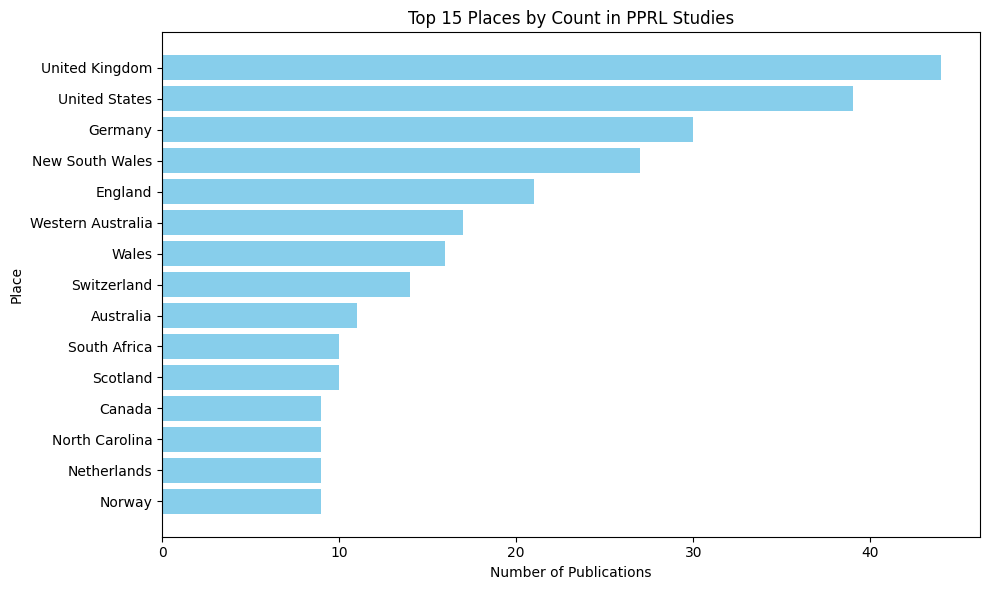

In [19]:
import matplotlib.pyplot as plt

# Aggregate counts per place
df_grouped = df_exploded.groupby(place_col, as_index=False)[count_col].sum()

# Top 15 places
df_top15 = df_grouped.sort_values(by=count_col, ascending=False).head(15)

print("Top 15 places:\n", df_top15)

# Plot
plt.figure(figsize=(10,6))
plt.barh(df_top15[place_col], df_top15[count_col], color="skyblue")
plt.gca().invert_yaxis()  # Highest count on top
plt.xlabel("Number of Publications")
plt.ylabel("Place")
plt.title("Top 15 Places by Count in PPRL Studies")
plt.tight_layout()
plt.savefig("top_places.png", dpi=300, bbox_inches="tight")
plt.show()


### World Map of Publications


In [20]:
import plotly.express as px

fig = px.choropleth(
    df_grouped,
    locations=place_col,
    locationmode="country names",
    color=count_col,
    hover_name=place_col,
    color_continuous_scale="Blues",
    title="Geographic Distribution of PPRL Publications"
)

# Show interactive map
fig.show()

# Skip writing to file if Kaleido/Chrome is not available
# fig.write_image("world_map.png", scale=2)  # Comment out for now


### Word Cloud of Places

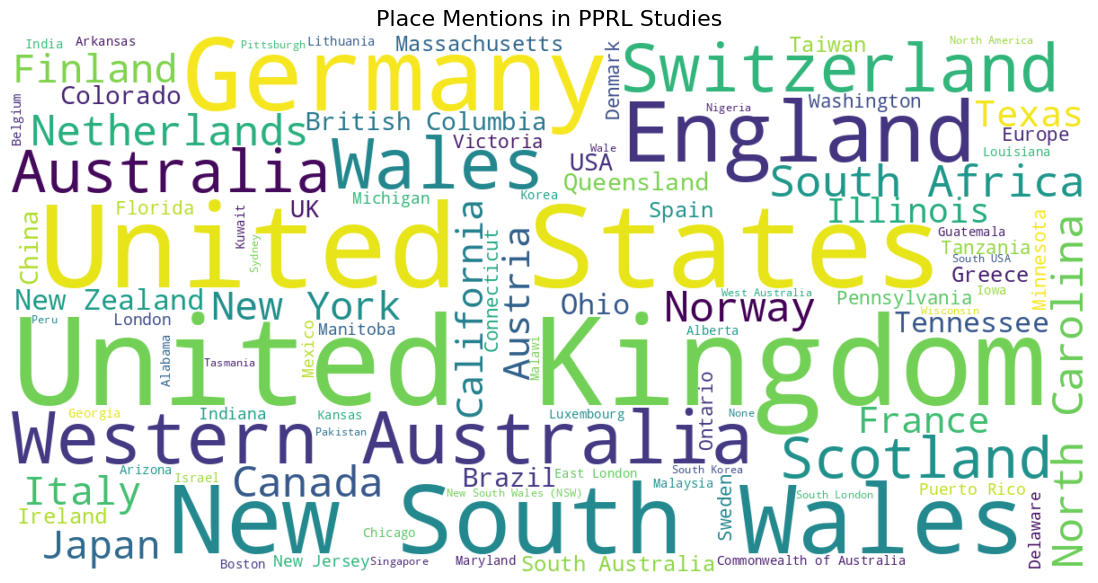

In [21]:
from wordcloud import WordCloud

# Make dictionary of place counts
freqs = dict(zip(df_grouped[place_col], df_grouped[count_col]))

wordcloud = WordCloud(width=1200, height=600, background_color="white").generate_from_frequencies(freqs)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Place Mentions in PPRL Studies", fontsize=16)
plt.savefig("place_wordcloud.png", dpi=300, bbox_inches="tight")
plt.show()


### Temporal Trends (Publications per Year)

Publications per year:
       year  count
0   2002.0      1
1   2003.0      1
2   2004.0      2
3   2005.0      1
4   2006.0      1
5   2007.0      3
6   2008.0      6
7   2009.0      3
8   2010.0      3
9   2011.0      2
10  2012.0      6
11  2013.0     26
12  2014.0     28
13  2015.0     28
14  2016.0     16
15  2017.0     31
16  2018.0     43
17  2019.0     26
18  2020.0     38
19  2021.0     29
20  2022.0     43
21  2023.0     26
22  2024.0     65
23  2025.0     58


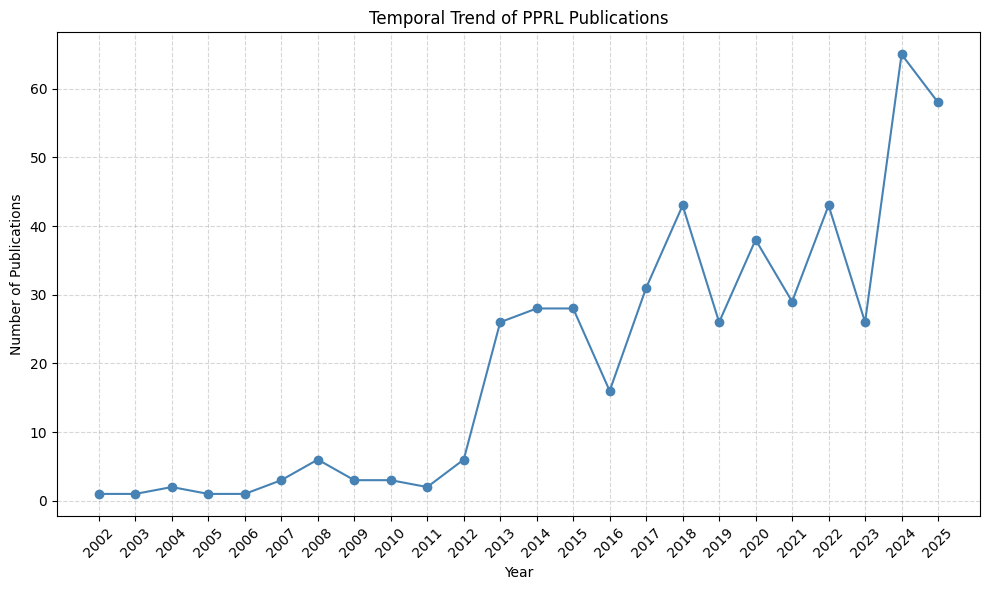

In [22]:
# Step 6a: Identify year column
year_col_candidates = ['year', 'publication_year', 'date', 'pub_year']
year_col = None
for c in year_col_candidates:
    if c in df_raw.columns:
        year_col = c
        break
if year_col is None:
    raise ValueError("Couldn't find a year column. Rename it to 'year' or 'publication_year' etc.")

# Ensure year is numeric
df_raw[year_col] = pd.to_numeric(df_raw[year_col], errors='coerce')

# Remove rows without year for plotting
df_year = df_raw[df_raw[year_col].notna()].copy()

# If there are multiple places per row, explode them like we did earlier
df_year = df_year.assign(
    **{place_col: df_year[place_col].str.split(";")}
).explode(place_col)
df_year[place_col] = df_year[place_col].str.strip()
df_year = df_year[df_year[place_col] != ""]

# Replace zero counts with 1
df_year[count_col] = df_year[count_col].replace(0, 1)

# Step 6b: Aggregate counts per year
df_year_grouped = df_year.groupby(year_col, as_index=False)[count_col].sum()
df_year_grouped = df_year_grouped.sort_values(year_col)

print("Publications per year:\n", df_year_grouped)

# Step 6c: Plot temporal trend
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(df_year_grouped[year_col], df_year_grouped[count_col], marker='o', color='steelblue')
plt.xlabel("Year")
plt.ylabel("Number of Publications")
plt.title("Temporal Trend of PPRL Publications")
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(df_year_grouped[year_col].astype(int), rotation=45)
plt.tight_layout()
plt.savefig("temporal_trend.png", dpi=300, bbox_inches="tight")
plt.show()


### Alternative (count) - ii

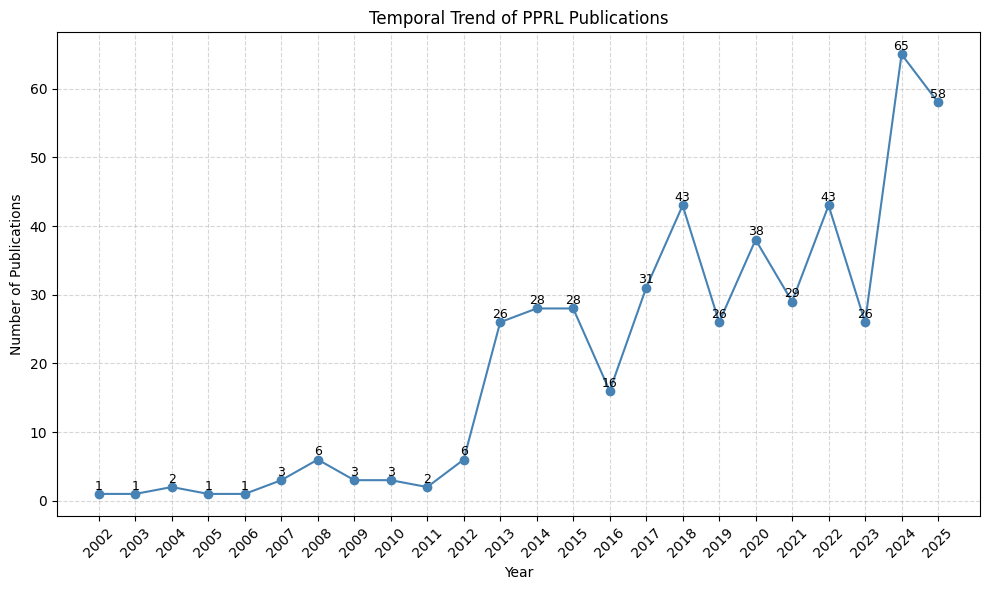

In [23]:
import matplotlib.pyplot as plt

# Aggregate counts per year (already cleaned/exploded)
df_year_grouped = df_year.groupby(year_col, as_index=False)[count_col].sum()
df_year_grouped = df_year_grouped.sort_values(year_col)

# Plot with data labels
plt.figure(figsize=(10,6))
plt.plot(df_year_grouped[year_col], df_year_grouped[count_col], marker='o', color='steelblue')

# Add labels for each point
for x, y in zip(df_year_grouped[year_col], df_year_grouped[count_col]):
    plt.text(x, y+0.2, str(int(y)), ha='center', va='bottom', fontsize=9)

plt.xlabel("Year")
plt.ylabel("Number of Publications")
plt.title("Temporal Trend of PPRL Publications")
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(df_year_grouped[year_col].astype(int), rotation=45)
plt.tight_layout()
plt.savefig("temporal_trend_with_labels.png", dpi=300, bbox_inches="tight")
plt.show()

### Alternative (%) iii

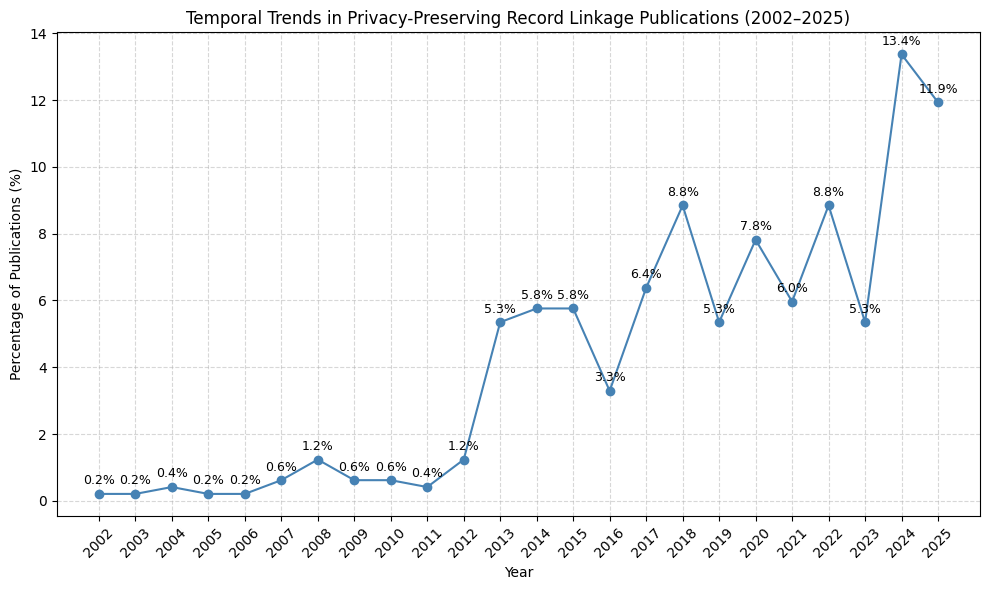

In [26]:
import matplotlib.pyplot as plt

# Aggregate counts per year
df_year_grouped = df_year.groupby(year_col, as_index=False)[count_col].sum()
df_year_grouped = df_year_grouped.sort_values(year_col)

# Calculate percentages
total_publications = df_year_grouped[count_col].sum()
df_year_grouped['percentage'] = (df_year_grouped[count_col] / total_publications) * 100

# Plot temporal trend with percentages
plt.figure(figsize=(10,6))
plt.plot(df_year_grouped[year_col], df_year_grouped['percentage'], marker='o', color='steelblue')

# Add percentage labels
for x, y in zip(df_year_grouped[year_col], df_year_grouped['percentage']):
    plt.text(x, y+0.2, f"{y:.1f}%", ha='center', va='bottom', fontsize=9)

plt.xlabel("Year")
plt.ylabel("Percentage of Publications (%)")
plt.title("Temporal Trends in Privacy-Preserving Record Linkage Publications (2002–2025)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(df_year_grouped[year_col].astype(int), rotation=45)
plt.tight_layout()
plt.savefig("temporal_trend_percentage.png", dpi=300, bbox_inches="tight")
plt.show()


#### Both count and percentages - latest

In [27]:
!pip install adjustText

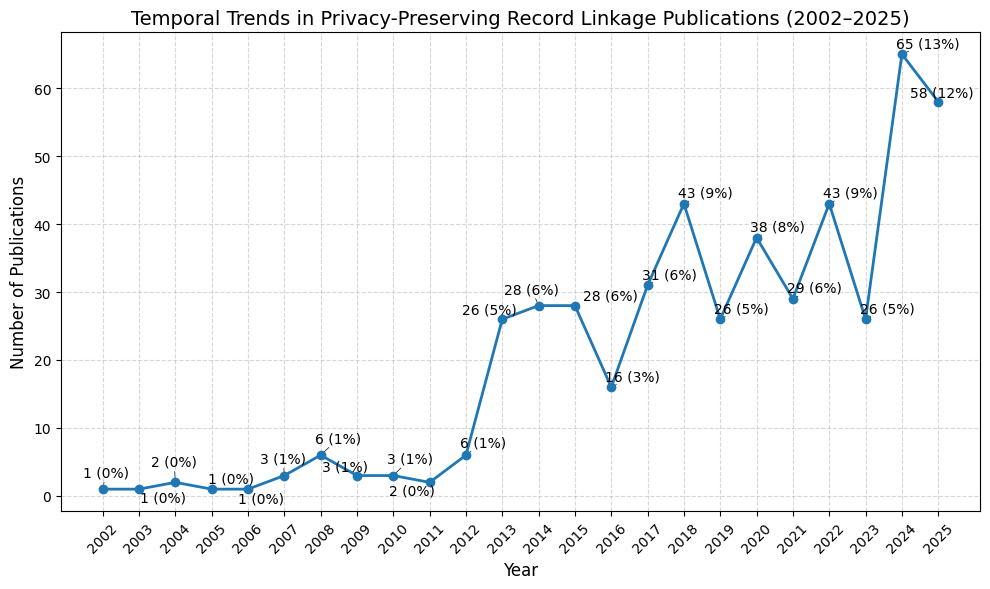

In [28]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

# Aggregate counts per year
df_year_grouped = df_year.groupby(year_col, as_index=False)[count_col].sum()
df_year_grouped = df_year_grouped.sort_values(year_col)

# Calculate percentages
total_pubs = df_year_grouped[count_col].sum()
df_year_grouped["percentage"] = (df_year_grouped[count_col] / total_pubs) * 100

# Plot
plt.figure(figsize=(10,6))
plt.plot(df_year_grouped[year_col], df_year_grouped[count_col], marker='o', linewidth=2)

# Store text objects
texts = []

for x, y, p in zip(df_year_grouped[year_col],
                   df_year_grouped[count_col],
                   df_year_grouped["percentage"]):

    label = f"{int(y)} ({p:.0f}%)"

    texts.append(
        plt.text(x, y, label, fontsize=10, ha='center', va='bottom')
    )

# Automatically adjust labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="-", lw=0.5))

# Axis labels
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Publications", fontsize=12)
plt.title("Temporal Trends in Privacy-Preserving Record Linkage Publications (2002–2025)", fontsize=14)

# Grid and ticks
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(df_year_grouped[year_col].astype(int), rotation=45)

plt.tight_layout()
plt.savefig("temporal_trend_publication_quality.png", dpi=300, bbox_inches="tight")
plt.show()

### Bubble Map

In [ ]:
import plotly.express as px

# Create the bubble map
fig = px.scatter_geo(
    df_grouped,
    locations=place_col,          # country names
    locationmode='country names',
    size=count_col,               # bubble size by number of publications
    hover_name=place_col,         # display country name on hover
    projection='natural earth',
    title='PPRL Implementation Across Countries',
    size_max=40,                  # max bubble size
    color=count_col,              # optional: color by count
    color_continuous_scale='Blues'
)

# Show interactive bubble map
fig.show()
fig.write_html("pprl_bubble_map.html")

### bubble Map - ii (lovely)

In [ ]:
import plotly.express as px

fig = px.scatter_geo(
    df_grouped,
    locations=place_col,
    locationmode='country names',
    size=count_col,
    hover_name=place_col,
    projection='natural earth',
    title='PPRL Implementation Across Countries',
    size_max=60,          # increase max bubble size
    color=count_col,
    color_continuous_scale='Viridis',  # darker/more contrasting colors
    opacity=0.8,
)

fig.update_traces(marker=dict(line=dict(width=1, color='DarkSlateGrey')))

fig.show()
fig.write_html("pprl_bubble_map_ii.html")
